<a href="https://colab.research.google.com/github/vvelvadapu9/DemoAIProj/blob/Dev/ML_model_AQI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Air Quality Index Prediction

In [ ]:
# Import required libraries and load the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('AQI.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
# Lets verify the percentage of missing values
df.isnull().sum()/len(df)*100


,0
City,0.000000
Date,0.000000
PM2.5,15.570079
PM10,37.723071
NO,12.129626
NO2,12.139785
NOx,14.171549
NH3,34.973418
CO,6.972334
SO2,13.050692


In [ ]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Observations:
PM10, NH3 Toloune Xylene Columns are having more missing values - Lets drop these columns /n

Columns data is an unimportant column, lets drop date column
AQI_bucket is another form of output and can be dropped

In [ ]:
df['AQI_Bucket'].value_counts()


,count
AQI_Bucket,
Moderate,8829
Satisfactory,8224
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


In [ ]:
# drop columns PM10, NH3, Toloune, Xylene
df= df.drop(columns=["PM10","NH3","Toluene","Xylene"])
df= df.drop(columns=["Date"])
df= df.drop(columns=["AQI_Bucket"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   City     29531 non-null  object 
 1   PM2.5    24933 non-null  float64
 2   NO       25949 non-null  float64
 3   NO2      25946 non-null  float64
 4   NOx      25346 non-null  float64
 5   CO       27472 non-null  float64
 6   SO2      25677 non-null  float64
 7   O3       25509 non-null  float64
 8   Benzene  23908 non-null  float64
 9   AQI      24850 non-null  float64
dtypes: float64(9), object(1)
memory usage: 2.3+ MB


In [ ]:
# Update null values of columns with relevant data
# use Median

df["PM2.5"]=df["PM2.5"].fillna(df["PM2.5"].median())
df["NO"]=df["NO"].fillna(df["NO"].median())
df["NO2"]=df["NO2"].fillna(df["NO2"].median())
df["NOx"]=df["NOx"].fillna(df["NOx"].median())
df["CO"]=df["CO"].fillna(df["CO"].median())
df["SO2"]=df["SO2"].fillna(df["SO2"].median())
df["O3"]=df["O3"].fillna(df["O3"].median())
df["Benzene"]=df["Benzene"].fillna(df["Benzene"].median())
df["AQI"]=df["AQI"].fillna(df["AQI"].median())

In [ ]:
# remove
df= df.drop_duplicates()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27197 entries, 0 to 29530
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   City     27197 non-null  object 
 1   PM2.5    27197 non-null  float64
 2   NO       27197 non-null  float64
 3   NO2      27197 non-null  float64
 4   NOx      27197 non-null  float64
 5   CO       27197 non-null  float64
 6   SO2      27197 non-null  float64
 7   O3       27197 non-null  float64
 8   Benzene  27197 non-null  float64
 9   AQI      27197 non-null  float64
dtypes: float64(9), object(1)
memory usage: 2.3+ MB


In [ ]:
# obtain relevant rows and columns using Shape
df.shape

(27197, 10)

AQI --- Target Variable

Excluding AQI, remaining are predictors

In [ ]:
# Target Variable
y=df["AQI"]
y.shape

(27197,)

In [ ]:

# Predictors (Input Variables)
X=df.drop(columns=["AQI"])
X.shape

(27197, 9)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27197 entries, 0 to 29530
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   City     27197 non-null  object 
 1   PM2.5    27197 non-null  float64
 2   NO       27197 non-null  float64
 3   NO2      27197 non-null  float64
 4   NOx      27197 non-null  float64
 5   CO       27197 non-null  float64
 6   SO2      27197 non-null  float64
 7   O3       27197 non-null  float64
 8   Benzene  27197 non-null  float64
dtypes: float64(8), object(1)
memory usage: 2.1+ MB


Splitting Data into train data and test data is required for validating the model
sklearn is used for splitting data between train data and test data.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(21757, 9)
(21757,)
(5440, 9)
(5440,)


In [ ]:
# Let us use column transformer to apply feature scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
transformer=ColumnTransformer(transformers=[("t1",OrdinalEncoder(),[0]),
          ("t2",StandardScaler(),[1,2,3,4,5,6,7,8])])

# Let us apply fit_transform on Train Data
X_train_trans=transformer.fit_transform(X_train)

#Let us apply transform on test data
X_test_trans=transformer.transform(X_test)



In [ ]:
print(type(X_train_trans))
print(type(X_test_trans))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
# Lets us convert X_train_trans into Data frame
X_train_trans=pd.DataFrame(X_train_trans)
X_train_trans.head()

,0,1,2,3,4,5,6,7,8
0,21.0,1.677586,0.246127,-0.152208,0.431102,-0.084112,-0.608514,-0.680028,-0.195069
1,15.0,-0.242316,-0.483958,-0.010687,-0.275741,-0.220316,-0.116895,-0.797434,-0.211208
2,23.0,-0.809957,1.011553,-0.943328,0.494201,-0.179042,0.532131,-1.351328,-0.211208
3,10.0,3.933940,4.302306,2.322357,0.564820,-0.271221,-0.147933,-0.229338,0.014740
4,25.0,-0.250389,-0.402092,-0.140278,-0.393439,-0.228571,-0.607406,0.613338,-0.211208


In [ ]:
#Let us convert X_test_trans into Data frame
X_test_trans=pd.DataFrame(X_test_trans)
X_test_trans.head()

,0,1,2,3,4,5,6,7,8
0,4.0,-0.568435,-0.339462,0.173208,-0.320858,-0.220316,-0.592441,0.415925,-0.211208
1,4.0,-0.145127,-0.429381,-0.132461,-0.183544,-0.205182,-0.592995,0.833476,-0.145950
2,4.0,-0.446706,-0.259386,0.150170,0.011966,-0.224443,-0.525931,1.106635,-0.178930
3,8.0,-0.383258,0.122209,0.370269,-0.119791,-0.224443,-0.201141,-0.511493,-0.192964
4,14.0,-0.853870,-0.429828,-0.056352,-0.788381,-0.295985,-0.247144,-0.442848,-0.209805


In [ ]:
#obtain unique categories
df["City"].nunique()

df["City"].value_counts()

,count
City,
Bengaluru,2009
Delhi,2009
Lucknow,1991
Hyderabad,1986
Chennai,1982
Patna,1664
Gurugram,1621
Mumbai,1484
Ahmedabad,1415


In [ ]:
# KNN Model Building
# If a target variable is real numerical and continuous use Regression and if its categorical (discrete classes) then use classification
# Regression vs Classification depends on type of target variable

from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
# fit the data
knn.fit(X_train_trans,y_train)


KNeighborsRegressor()

In [ ]:
y_pred=knn.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(5440,)
(5440,)


In [ ]:
# Let us evaluate the model using r2 score
from sklearn.metrics import r2_score
score=r2_score(y_pred,y_test)
print("R2 score of KNN model is", score)

R2 score of KNN model is 0.8029303049510533


In [ ]:
# Let us evaluate the model using r2 score
from sklearn.metrics import r2_score
score1=r2_score(y_test,y_pred)
print("R2 score of KNN model is", score)

R2 score of KNN model is 0.8029303049510533


In [ ]:
y_pred =knn.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)


(5440,)
(5440,)


R2 is Usually 0 to 1. 1 being perfect predictions 0 not good. It can also be negative which means model performs worse than predicting the mean.

Mean Absolute Error - Average absolute difference between predictions and actual values. (Unit is Same as the target variable)

Mean Squared Error - Average squared prediction error. (Unit is Square of target variable)

Root Mean Squared Error - Square root of Mean squared error. (Unit same as target variable)



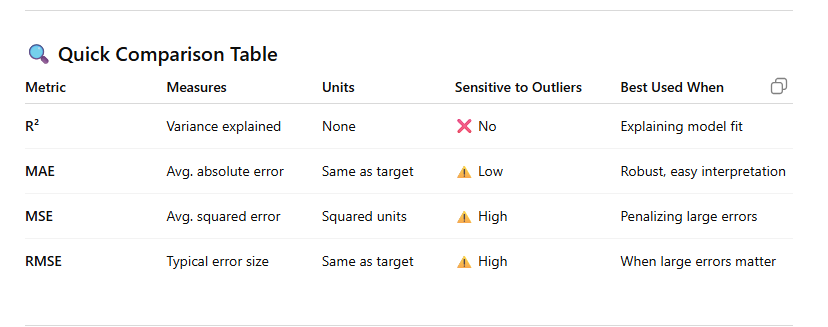

In [ ]:
# R2 range 0-1; Mean Absolute Error has lower bound 0 no upper bound;  Mean Squared Error

# Metric 1: Mean Absolute Error
from sklearn.metrics import mean_absolute_error
MAE=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error of KNN Model is", MAE)

# Metric 2: Mean Squared Error
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(y_test,y_pred)
print("Mean Squared Error of KNN Model is", MSE)

#Metric 3: Root Mean Square Error (RMSE)
from sklearn.metrics import root_mean_squared_error
RMSE = root_mean_squared_error(y_test,y_pred)
print("Root Mean Squared Error of KNN Model is", RMSE)




Mean Absolute Error of KNN Model is 25.50018382352941
Mean Squared Error of KNN Model is 2775.939904411765
Root Mean Squared Error of KNN Model is 52.687189186857985


**Decision Tree Algorithm**


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor()
dtr.fit(X_train_trans,y_train)

# Let us make predictions using Decision tree model
y_pred=dtr.predict(X_test_trans)

#Let us validate the decision tree model
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R2 Score of Decision Tree Model is", score)


from sklearn.metrics import mean_absolute_error
MAE=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error of Decision Tree Model is", MAE)

from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(y_test, y_pred)
print("Mean Squared Error of Decision Tree Model is", MSE)

from sklearn.metrics import root_mean_squared_error
RMSE = root_mean_squared_error(y_test,y_pred)
print("Root Mean Squared Error of Decision Tree Model is", RMSE)


R2 Score of Decision Tree Model is 0.7216373434166388
Mean Absolute Error of Decision Tree Model is 32.7672181372549
Mean Squared Error of Decision Tree Model is 4570.933688214869
Root Mean Squared Error of Decision Tree Model is 67.60868056851035


In [ ]:
#Linear Regression Algorithm

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_trans,y_train)

# Making Prediction
y_pred=lr.predict(X_test_trans)

#Let us validate Linear Regression Model
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R2 score of Linear Regression Model is",score)

#Using Mean Absolute Error
from sklearn.metrics import mean_absolute_error
MAE=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error of Linear Regression Model is", MAE)

from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(y_test, y_pred)
print("Mean Squared Error of Linear Regression Model is", MSE)

from sklearn.metrics import root_mean_squared_error
RMSE = root_mean_squared_error(y_test,y_pred)
print("Root Mean Squared Error of Linear Regression Model is ", RMSE)




R2 score of Linear Regression Model is 0.759686424762904
Mean Absolute Error of Linear Regression Model is 34.055647554763226
Mean Squared Error of Linear Regression Model is 4009.8239957854016
Root Mean Squared Error of Linear Regression Model is  63.32317108125115


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor()
rfr.fit(X_train_trans,y_train)

#Predictions
y_pred=rfr.predict(X_test_trans)

#Let us validate using R2 Score
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R2 Score of Random Forest Model is", score)

from sklearn.metrics import mean_absolute_error
MAE=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error of Random Forest Model is", MAE)

from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(y_test, y_pred)
print("Mean Squared Error of Random Forest Model is", MSE)

from sklearn.metrics import root_mean_squared_error
RMSE = root_mean_squared_error(y_test,y_pred)
print("Root Mean Squared Error of Random Forest Model is ", RMSE)


R2 Score of Random Forest Model is 0.861787862179115
Mean Absolute Error of Random Forest Model is 23.298465342163965
Mean Squared Error of Random Forest Model is 2269.5519745353745
Root Mean Squared Error of Random Forest Model is  47.63981501365611


Comparing the four algorigthms

Quick Recommendations

Simple, explainable model: Linear Regression or Decision Tree

Small dataset, simple logic: KNN

Complex data, best performance: Random Forest

Nonlinear patterns: Decision Tree or Random Forest

1. K-Nearest Neighbors (KNN)

Type:Supervised
Used for classification and regression
How it works:
Finds the K closest data points to a new input

Predicts using the average (regression) or majority vote (classification)

2. Linear Regression

Type: Supervised
Used for regression only

How it works: Fits a straight line (or hyperplane) that minimizes prediction error

3. Decision Tree

Type: Supervised
Used for classification and regression

How it works: Splits data into branches based on feature conditions
Makes decisions by following the tree

4. Random Forest

Type:Supervised (Ensemble method)
Used for classification and regression

How it works:Builds many decision trees
Combines their predictions (averaging or voting)

In [ ]:
#Adaptive Boost Regressor

from sklearn.ensemble import AdaBoostRegressor
abr = AdaBoostRegressor()
abr.fit(X_train_trans, y_train)

y_pred = abr.predict(X_test_trans)

#validate using R2 score
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print("R2 Score of AdaBoost Regressor Model is", score)

#validate using mean absolute error
from sklearn.metrics import mean_absolute_error
MAE = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error of AdaBoost Regressor Model is", MAE)

from sklearn.metrics import mean_squared_error
MSE = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error of AdaBoost Regressor Model is", MSE)

from sklearn.metrics import root_mean_squared_error
RMSE = root_mean_squared_error(y_test, y_pred)
print("Root Mean Squared Error of AdaBoost Regressor Model is", RMSE)





R2 Score of AdaBoost Regressor Model is -1.0506444723116708
Mean Absolute Error of AdaBoost Regressor Model is 169.21107404837866
Mean Squared Error of AdaBoost Regressor Model is 169.21107404837866
Root Mean Squared Error of AdaBoost Regressor Model is 184.97740763492212
